In [1]:
!pip install pgmpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pgmpy.estimators import MaximumLikelihoodEstimator, ExpectationMaximization
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from sklearn.metrics import classification_report

In [6]:
train_df = pd.read_csv('balanced_train-2.csv')
test_df = pd.read_csv('balanced_test-2.csv')

train_df['bank_months_count'] = train_df['bank_months_count'].replace(-1, np.nan)
test_df['bank_months_count'] = test_df['bank_months_count'].replace(-1, np.nan)

train_df.head()
test_df.head()

,fraud_bool,email_is_free,bank_months_count,payment_type,keep_alive_session,has_other_cards,age_bin,income_bin,credit_bin,bank_bin,name_email_bin,velocity_24h_bin
0,0,1,30.0,1,0,0,young,upper class,very low credit,long term,low similarity,high
1,1,0,31.0,1,0,0,old,lower class,high credit,long term,medium similarity,medium
2,0,0,NaN,2,0,0,old,lower class,high credit,short term,high similarity,medium
3,0,1,11.0,1,1,1,young,upper class,very high credit,medium term,low similarity,very low
4,1,1,10.0,0,0,0,middle-aged,middle class,medium credit,medium term,very low similarity,very high


In [7]:
# impute bank_months_count with average
train_df['bank_months_count'] = train_df['bank_months_count'].fillna(train_df['bank_months_count'].mean())
test_df['bank_months_count'] = test_df['bank_months_count'].fillna(test_df['bank_months_count'].mean())

In [8]:
# descretize
train_df['bank_bin'] = pd.qcut(train_df['bank_months_count'], q=3, labels=['short term','medium term','long term'])
test_df['bank_bin'] = pd.qcut(test_df['bank_months_count'], q=3, labels=['short term','medium term','long term'])

# MLE on Small BN

In [9]:
train_small_df = train_df[['fraud_bool', 'income_bin', 'age_bin', 'credit_bin', 'bank_bin']].copy()
test_small_df = test_df[['fraud_bool', 'income_bin', 'age_bin', 'credit_bin', 'bank_bin']].copy()
train_small_df

,fraud_bool,income_bin,age_bin,credit_bin,bank_bin
0,0,lower class,young,high credit,medium term
1,0,middle class,young,very low credit,short term
2,0,middle class,middle-aged,high credit,short term
3,0,upper class,young,low credit,short term
4,1,lower class,young,very high credit,short term
...,...,...,...,...,...
52934,0,middle class,middle-aged,very high credit,long term
52935,0,lower class,middle-aged,medium credit,short term
52936,0,middle class,middle-aged,very high credit,long term
52937,0,lower class,old,very high credit,short term


In [10]:
model = DiscreteBayesianNetwork([('fraud_bool', 'age_bin'),('fraud_bool', 'income_bin'),('fraud_bool', 'credit_bin'), ('fraud_bool', 'bank_bin')])
model.fit(train_small_df, estimator=MaximumLikelihoodEstimator)

for cpt in model.get_cpds():
  print(cpt)


+---------------+----------+
| fraud_bool(0) | 0.833336 |
+---------------+----------+
| fraud_bool(1) | 0.166664 |
+---------------+----------+
+----------------------+---------------------+---------------------+
| fraud_bool           | fraud_bool(0)       | fraud_bool(1)       |
+----------------------+---------------------+---------------------+
| age_bin(middle-aged) | 0.23977695167286245 | 0.25966224640145075 |
+----------------------+---------------------+---------------------+
| age_bin(old)         | 0.17857466678756007 | 0.3877365975291851  |
+----------------------+---------------------+---------------------+
| age_bin(young)       | 0.5816483815395774  | 0.35260115606936415 |
+----------------------+---------------------+---------------------+
+--------------------------+---------------------+---------------------+
| fraud_bool               | fraud_bool(0)       | fraud_bool(1)       |
+--------------------------+---------------------+---------------------+
| income_bin(lo

In [11]:
target = 'fraud_bool'

X_test = test_small_df.drop(target, axis=1)
y_test = test_small_df[target]

inference = VariableElimination(model)

y_prob = [] # list for predicted probabilities of fraud
y_pred = [] # either 0 or 1

for _, row in X_test.iterrows():
    evidence = {'age_bin': row['age_bin'], 'income_bin': row['income_bin'], 'credit_bin': row['credit_bin'], 'bank_bin': row['bank_bin']}
    result = inference.query(variables=['fraud_bool'], evidence=evidence)
    prob = result.values[1]
    y_prob.append(prob)
    if prob > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)


print('\nModel Evaluation of MLE')
print(f'Classification Report:\n{classification_report(y_test, y_pred)}')


Model Evaluation of MLE
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     11029
           1       0.56      0.17      0.26      2206

    accuracy                           0.84     13235
   macro avg       0.71      0.57      0.59     13235
weighted avg       0.81      0.84      0.80     13235



# MLE on Large BN

In [12]:
train_big_df = train_df.copy()
test_big_df = test_df.copy()


In [13]:
model = DiscreteBayesianNetwork([('fraud_bool', 'age_bin'),('fraud_bool', 'income_bin'),('fraud_bool', 'credit_bin'), ('fraud_bool', 'bank_bin'),
                                 ('fraud_bool', 'name_email_bin'),('fraud_bool', 'payment_type'),('fraud_bool', 'keep_alive_session'),
                                 ('fraud_bool', 'has_other_cards'),('fraud_bool', 'velocity_24h_bin'),('fraud_bool', 'email_is_free')])

model.fit(train_big_df, estimator=MaximumLikelihoodEstimator)

for cpt in model.get_cpds():
  print(cpt)

+---------------+----------+
| fraud_bool(0) | 0.833336 |
+---------------+----------+
| fraud_bool(1) | 0.166664 |
+---------------+----------+
+----------------------+---------------------+---------------------+
| fraud_bool           | fraud_bool(0)       | fraud_bool(1)       |
+----------------------+---------------------+---------------------+
| age_bin(middle-aged) | 0.23977695167286245 | 0.25966224640145075 |
+----------------------+---------------------+---------------------+
| age_bin(old)         | 0.17857466678756007 | 0.3877365975291851  |
+----------------------+---------------------+---------------------+
| age_bin(young)       | 0.5816483815395774  | 0.35260115606936415 |
+----------------------+---------------------+---------------------+
+--------------------------+---------------------+---------------------+
| fraud_bool               | fraud_bool(0)       | fraud_bool(1)       |
+--------------------------+---------------------+---------------------+
| income_bin(lo

In [14]:
target = 'fraud_bool'

X_test = test_big_df.drop(target, axis=1)
y_test = test_big_df[target]

inference = VariableElimination(model)

y_prob = [] # list for predicted probabilities of fraud
y_pred = [] # either 0 or 1

for _, row in X_test.iterrows():
    evidence = {'age_bin': row['age_bin'], 'income_bin': row['income_bin'], 'credit_bin': row['credit_bin'],
                'name_email_bin': row['name_email_bin'], 'payment_type': row['payment_type'],'keep_alive_session': row['keep_alive_session'],
                'velocity_24h_bin': row['velocity_24h_bin'],'email_is_free': row['email_is_free'], 'bank_bin': row['bank_bin']}
    result = inference.query(variables=['fraud_bool'], evidence=evidence)
    prob = result.values[1]
    y_prob.append(prob)
    if prob > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)


print('\nModel Evaluation of EM')
print(f'Classification Report:\n{classification_report(y_test, y_pred)}')


Model Evaluation of EM
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     11029
           1       0.57      0.32      0.41      2206

    accuracy                           0.85     13235
   macro avg       0.72      0.63      0.66     13235
weighted avg       0.82      0.85      0.83     13235



# MLE on Small BN (new balanced data)

In [4]:
train2_df = pd.read_csv('balanced_train.csv')
test2_df = pd.read_csv('balanced_test.csv')

train2_df['bank_months_count'] = train2_df['bank_months_count'].replace(-1, np.nan)
test2_df['bank_months_count'] = test2_df['bank_months_count'].replace(-1, np.nan)

train2_df.head()
test2_df.head()

,fraud_bool,email_is_free,bank_months_count,payment_type,keep_alive_session,has_other_cards,age_bin,income_bin,credit_bin,bank_bin,name_email_bin,velocity_24h_bin
0,0,1,30.0,1,0,0,young,upper class,very low credit,long term,low similarity,high
1,1,0,31.0,1,0,0,old,lower class,high credit,long term,medium similarity,medium
2,0,0,NaN,2,0,0,old,lower class,high credit,short term,high similarity,medium
3,0,1,11.0,1,1,1,young,upper class,very high credit,medium term,low similarity,very low
4,1,1,10.0,0,0,0,middle-aged,middle class,medium credit,medium term,very low similarity,very high


In [5]:
# impute bank_months_count with average
train2_df['bank_months_count'] = train2_df['bank_months_count'].fillna(train2_df['bank_months_count'].mean())
test2_df['bank_months_count'] = test2_df['bank_months_count'].fillna(test2_df['bank_months_count'].mean())

In [6]:
# descretize
train2_df['bank_bin'] = pd.qcut(train2_df['bank_months_count'], q=3, labels=['short term','medium term','long term'])
test2_df['bank_bin'] = pd.qcut(test2_df['bank_months_count'], q=3, labels=['short term','medium term','long term'])

In [7]:
train2_small_df = train2_df[['fraud_bool', 'income_bin', 'age_bin', 'credit_bin', 'bank_bin']].copy()
test2_small_df = test2_df[['fraud_bool', 'income_bin', 'age_bin', 'credit_bin', 'bank_bin']].copy()
train2_small_df

,fraud_bool,income_bin,age_bin,credit_bin,bank_bin
0,0,lower class,young,high credit,medium term
1,0,middle class,young,very low credit,short term
2,0,middle class,middle-aged,high credit,short term
3,0,upper class,young,low credit,short term
4,1,lower class,young,very high credit,short term
...,...,...,...,...,...
52934,0,middle class,middle-aged,very high credit,long term
52935,0,lower class,middle-aged,medium credit,short term
52936,0,middle class,middle-aged,very high credit,long term
52937,0,lower class,old,very high credit,short term


In [8]:
model = DiscreteBayesianNetwork([('fraud_bool', 'age_bin'),('fraud_bool', 'income_bin'),('fraud_bool', 'credit_bin'), ('fraud_bool', 'bank_bin')])
model.fit(train2_small_df, estimator=MaximumLikelihoodEstimator)

for cpt in model.get_cpds():
  print(cpt)

+---------------+----------+
| fraud_bool(0) | 0.833336 |
+---------------+----------+
| fraud_bool(1) | 0.166664 |
+---------------+----------+
+----------------------+---------------------+---------------------+
| fraud_bool           | fraud_bool(0)       | fraud_bool(1)       |
+----------------------+---------------------+---------------------+
| age_bin(middle-aged) | 0.23977695167286245 | 0.25966224640145075 |
+----------------------+---------------------+---------------------+
| age_bin(old)         | 0.17857466678756007 | 0.3877365975291851  |
+----------------------+---------------------+---------------------+
| age_bin(young)       | 0.5816483815395774  | 0.35260115606936415 |
+----------------------+---------------------+---------------------+
+--------------------------+---------------------+---------------------+
| fraud_bool               | fraud_bool(0)       | fraud_bool(1)       |
+--------------------------+---------------------+---------------------+
| income_bin(lo

In [9]:
target = 'fraud_bool'

X_test = test2_small_df.drop(target, axis=1)
y_test = test2_small_df[target]

inference = VariableElimination(model)

y_prob = [] # list for predicted probabilities of fraud
y_pred = [] # either 0 or 1

for _, row in X_test.iterrows():
    evidence = {'age_bin': row['age_bin'], 'income_bin': row['income_bin'], 'credit_bin': row['credit_bin'], 'bank_bin': row['bank_bin']}
    result = inference.query(variables=['fraud_bool'], evidence=evidence)
    prob = result.values[1]
    y_prob.append(prob)
    if prob > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)


print('\nModel Evaluation of MLE (new balanced data)')
print(f'Classification Report:\n{classification_report(y_test, y_pred)}')


Model Evaluation of MLE (new balanced data)
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     11029
           1       0.56      0.17      0.26      2206

    accuracy                           0.84     13235
   macro avg       0.71      0.57      0.59     13235
weighted avg       0.81      0.84      0.80     13235



# MLE on Large BN (new balanced data)

In [13]:
train2_big_df = train2_df.copy()
test2_big_df = test2_df.copy()


In [14]:
model = DiscreteBayesianNetwork([('fraud_bool', 'age_bin'),('fraud_bool', 'income_bin'),('fraud_bool', 'credit_bin'), ('fraud_bool', 'bank_bin'),
                                 ('fraud_bool', 'name_email_bin'),('fraud_bool', 'payment_type'),('fraud_bool', 'keep_alive_session'),
                                 ('fraud_bool', 'has_other_cards'),('fraud_bool', 'velocity_24h_bin'),('fraud_bool', 'email_is_free')])

model.fit(train2_big_df, estimator=MaximumLikelihoodEstimator)

for cpt in model.get_cpds():
  print(cpt)

+---------------+----------+
| fraud_bool(0) | 0.833336 |
+---------------+----------+
| fraud_bool(1) | 0.166664 |
+---------------+----------+
+----------------------+---------------------+---------------------+
| fraud_bool           | fraud_bool(0)       | fraud_bool(1)       |
+----------------------+---------------------+---------------------+
| age_bin(middle-aged) | 0.23977695167286245 | 0.25966224640145075 |
+----------------------+---------------------+---------------------+
| age_bin(old)         | 0.17857466678756007 | 0.3877365975291851  |
+----------------------+---------------------+---------------------+
| age_bin(young)       | 0.5816483815395774  | 0.35260115606936415 |
+----------------------+---------------------+---------------------+
+--------------------------+---------------------+---------------------+
| fraud_bool               | fraud_bool(0)       | fraud_bool(1)       |
+--------------------------+---------------------+---------------------+
| income_bin(lo

In [15]:
target = 'fraud_bool'

X_test = test2_big_df.drop(target, axis=1)
y_test = test2_big_df[target]

inference = VariableElimination(model)

y_prob = [] # list for predicted probabilities of fraud
y_pred = [] # either 0 or 1

for _, row in X_test.iterrows():
    evidence = {'age_bin': row['age_bin'], 'income_bin': row['income_bin'], 'credit_bin': row['credit_bin'],
                'name_email_bin': row['name_email_bin'], 'payment_type': row['payment_type'],'keep_alive_session': row['keep_alive_session'],
                'velocity_24h_bin': row['velocity_24h_bin'],'email_is_free': row['email_is_free'], 'bank_bin': row['bank_bin']}
    result = inference.query(variables=['fraud_bool'], evidence=evidence)
    prob = result.values[1]
    y_prob.append(prob)
    if prob > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)


print('\nModel Evaluation of EM (new balanced data)')
print(f'Classification Report:\n{classification_report(y_test, y_pred)}')


Model Evaluation of EM (new balanced data)
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     11029
           1       0.57      0.32      0.41      2206

    accuracy                           0.85     13235
   macro avg       0.72      0.63      0.66     13235
weighted avg       0.82      0.85      0.83     13235



# Large Model Evaluation with thresholds (new balanced data)

In [ ]:
# target = 'fraud_bool'

# X_test = test2_big_df.drop(target, axis=1)
# y_test = test2_big_df[target]

# inference = VariableElimination(model)

# # collect probabilities
# y_prob = []
# for _, row in X_test.iterrows():
#     evidence = {
#         'age_bin': row['age_bin'],
#         'income_bin': row['income_bin'],
#         'credit_bin': row['credit_bin'],
#         'name_email_bin': row['name_email_bin'],
#         'payment_type': row['payment_type'],
#         'keep_alive_session': row['keep_alive_session'],
#         'velocity_24h_bin': row['velocity_24h_bin'],
#         'email_is_free': row['email_is_free'],
#         'bank_bin': row['bank_bin']
#     }

#     result = inference.query(variables=['fraud_bool'], evidence=evidence)
#     prob = result.values[1]
#     y_prob.append(prob)

# # threshold tuning
# from sklearn.metrics import precision_score, recall_score

# thresholds = [0.5, 0.3]

# print('\nThreshold Tuning Results on EM (new balanced data)')

# for t in thresholds:
#     y_pred_t = []
#     for p in y_prob:
#         if p > t:
#             y_pred_t.append(1)
#         else:
#             y_pred_t.append(0)

#     precision = precision_score(y_test, y_pred_t)
#     recall = recall_score(y_test, y_pred_t)

#     print(f"\nThreshold {t}")
#     print(f"Precision: {precision:.3f}")
#     print(f"Recall:    {recall:.3f}")

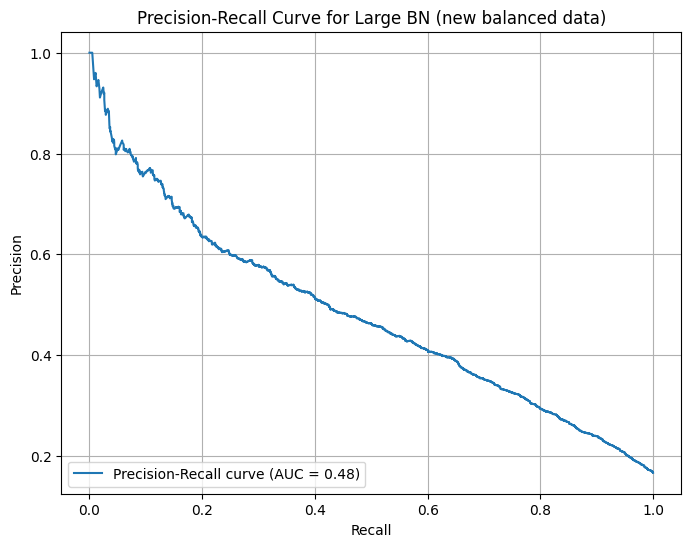

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Calculate precision and recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Calculate Area Under the Curve (AUC)
pr_auc = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Large BN (new balanced data)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()